In [2]:
import os 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from locscale.include.emmer.ndimage.map_utils import load_map 

parent_dir = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_3061/epistemic_uncertainty/epoch_evolution_monte_carlo"

In [3]:
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
final_epoch = 14

mean_maps_path = {e: os.path.join(parent_dir, f"epoch_{e}", f"output_map_epoch_{e}_mean.mrc") for e in epochs}
var_maps_path = {e: os.path.join(parent_dir, f"epoch_{e}", f"output_map_epoch_{e}_var.mrc") for e in epochs}

assert all([os.path.exists(p) for p in mean_maps_path.values()])
assert all([os.path.exists(p) for p in var_maps_path.values()])


In [38]:
final_mean_map, apix = load_map(mean_maps_path[final_epoch])
# get mask for final mean map in the calibration range 
calibration_region = final_mean_map > 0.1 
# only sample a subset of points for correlation analysis to speed up computation
n_sample = 500
calibration_region = np.where(calibration_region)
if len(calibration_region[0]) > n_sample:
    sampled_indices = np.random.choice(len(calibration_region[0]), size=n_sample, replace=False)
    calibration_region = (calibration_region[0][sampled_indices], calibration_region[1][sampled_indices], calibration_region[2][sampled_indices])

print(f"Choosen calibration region has {len(calibration_region[0])} voxels")
final_var_map = load_map(var_maps_path[final_epoch])[0]
final_variance_values = final_var_map[calibration_region]

correlations = {}
var_vals = {}
for epoch in epochs: 
    var_map = load_map(var_maps_path[epoch])[0]
    var_values = var_map[calibration_region]

    # compute correlation between variance values at this epoch and final variance values
    corr = np.corrcoef(var_values, final_variance_values)[0, 1]
    correlations[epoch] = corr
    var_vals[epoch] = (var_values, final_variance_values)
    print(f"Epoch {epoch}: Correlation with final variance values = {corr:.4f}")


Choosen calibration region has 500 voxels
Epoch 1: Correlation with final variance values = 0.0169
Epoch 2: Correlation with final variance values = -0.0016
Epoch 3: Correlation with final variance values = 0.8319
Epoch 4: Correlation with final variance values = 0.9134
Epoch 5: Correlation with final variance values = 0.9305
Epoch 6: Correlation with final variance values = 0.9419
Epoch 7: Correlation with final variance values = 0.9683
Epoch 8: Correlation with final variance values = 0.9779
Epoch 9: Correlation with final variance values = 0.9795
Epoch 10: Correlation with final variance values = 0.9834
Epoch 11: Correlation with final variance values = 0.9616
Epoch 12: Correlation with final variance values = 0.9904
Epoch 13: Correlation with final variance values = 0.9818
Epoch 14: Correlation with final variance values = 1.0000


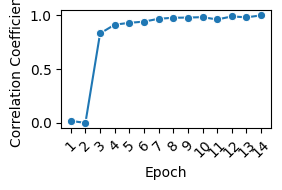

In [55]:
# plot correlations 
plt.figure(figsize=(3, 2))
sns.lineplot(x=list(correlations.keys()), y=list(correlations.values()), marker='o')
#plt.title("Spatial Correlation of Variance Maps with Final Epoch Variance Map")
plt.xlabel("Epoch")
plt.ylabel("Correlation Coefficient")
plt.xticks(epochs, rotation=45);
plt.tight_layout()
plt.savefig(os.path.join(parent_dir, "variance_correlation_with_final_epoch.pdf"), dpi=600)



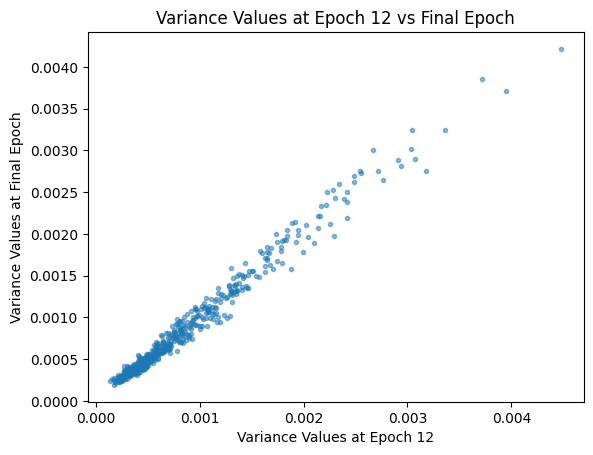

In [40]:
plot_epoch = 12
plt.plot(var_vals[plot_epoch][0], var_vals[plot_epoch][1], '.', alpha=0.5)
plt.title(f"Variance Values at Epoch {plot_epoch} vs Final Epoch")
plt.xlabel(f"Variance Values at Epoch {plot_epoch}")
plt.ylabel("Variance Values at Final Epoch")
plt.show()

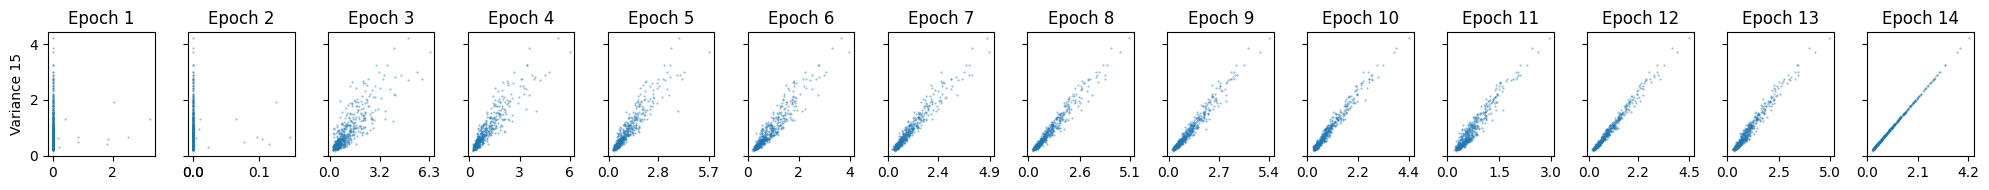

In [46]:
# plot as a series of subplots
fig, axes = plt.subplots(1, 14, figsize=(20, 2))
for i, epoch in enumerate(epochs):
    ax = axes[i]
    epoch_variance_values = var_vals[epoch][0]
    final_variance_values = var_vals[epoch][1]
    #ax.plot(epoch_variance_values[sampled_indices]*1000, final_variance_values[sampled_indices]*1000, '.', alpha=0.5, markersize=1)
    ax.plot(epoch_variance_values*1000, final_variance_values*1000, '.', alpha=0.5, markersize=1)
    ax.set_title(f"Epoch {epoch}")
    #ax.set_xlabel(f"Variance at Epoch {epoch}")
    #ax.set_ylabel("Variance at Final Epoch")
    # hide y labels for all but the first subplot
    ax.set_yticks([0, 2, 4])
    if i > 0:
        # set three ticks, min, mean and max
        min_x = 0
        max_x = round(np.max(epoch_variance_values)*1000, 1)
        mean_x = round((min_x + max_x) / 2,1)
        ax.set_xticks([min_x, mean_x, max_x])
        #ax.set_xticks([0, 2, 4])
        ax.set_yticklabels([])
        
    else:
        ax.set_ylabel("Variance 15")
        
    #ax.set_xticks([0, 0.0025, 0.005])
    #ax.set_xticklabels([f"{x*1000}" for x in [0, 0.0025, 0.005]])
plt.tight_layout()
output_path = os.path.join(parent_dir, "variance_correlation_plots.pdf")
plt.savefig(output_path, bbox_inches='tight', dpi=600)